In [1]:
import os
import pandas as pd
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def tflog2pandas(path):
    runlog_data = pd.DataFrame()
    ea = event_accumulator.EventAccumulator(path)
    ea.Reload()

    tags = ea.Tags()['scalars']

    for tag in tags:
        event_list = ea.Scalars(tag)
        values = [e.value for e in event_list]
        steps = [e.step for e in event_list]
        tag_df = pd.DataFrame({tag: values, 'step': steps})
        
        if runlog_data.empty:
            runlog_data = tag_df
        else:
            runlog_data = pd.merge(runlog_data, tag_df, on="step", how="outer")

    return runlog_data


In [3]:
# log_path = "../src/runs/rl/espov3/run8"
# log_path = "../src/runs/rl/final_large_runs/no_conditioning/run2"
log_path = "../src/runs/rl/final_large_runs/conditioning_with_move/run2"
# log_path = "../src/runs/rl/final_large_runs/test/run5"
df = tflog2pandas(log_path)
df.index = range(len(df))

In [4]:
df

,Components/legal_rate,step,Components/uniqueness_rate,Components/counter_intuitive_rate,Components/counter_intuitive_rate_given_unique,Components/unique_and_counter_intuitive,Components/entropy,Components/piece_counts,Components/dist_inter_fen,Components/dist_intra_fen,...,Components/all_dist,Components/pass_diversity_filtering,Components/move_match_rate,Components/cp_loss,Loss/Total Loss,Loss/RL Grad Norm,Loss/KL divergence,Loss/Clips,Loss/learning_rate,Reward
0,0.968750,0,0.218750,0.312500,0.000000,0.000000,0.586851,0.967742,14.209678,17.112904,...,0.290323,0.935484,0.532258,172.92308,-0.010740,0.417672,0.155174,0.005859,0.000003,-0.062500
1,0.968750,1,0.281250,0.312500,0.000000,0.000000,0.599122,0.951613,14.080646,17.258064,...,0.290323,0.919355,0.693548,0.00000,-0.011699,0.391405,0.140988,0.004883,0.000003,-0.062500
2,0.937500,2,0.265625,0.250000,0.058824,0.015625,0.561022,0.966667,14.666667,17.549999,...,0.216667,0.900000,0.616667,0.00000,-0.013417,0.570141,0.132901,0.011719,0.000003,-0.109375
3,0.921875,3,0.156250,0.312500,0.000000,0.000000,0.570463,0.966102,14.508474,16.932203,...,0.254237,0.847458,0.661017,0.00000,-0.013722,0.509702,0.154113,0.008789,0.000003,-0.156250
4,0.984375,4,0.250000,0.312500,0.062500,0.015625,0.581447,1.000000,15.031746,18.365080,...,0.333333,0.873016,0.571429,89.18750,-0.007617,0.444951,0.101152,0.003906,0.000003,-0.015625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1673,0.953125,1673,0.250000,0.359375,0.062500,0.015625,0.655612,0.950820,14.836065,17.688524,...,0.278689,0.868852,0.639344,0.00000,-0.004452,0.536832,0.349619,0.008789,0.000003,-0.078125
1674,1.000000,1674,0.187500,0.343750,0.083333,0.015625,0.649488,1.000000,14.421875,17.593750,...,0.296875,0.968750,0.437500,112.50000,-0.003666,0.413833,0.224552,0.007812,0.000003,0.015625
1675,0.984375,1675,0.156250,0.328125,0.100000,0.015625,0.620897,0.968254,14.444445,17.269842,...,0.206349,0.904762,0.555556,0.00000,-0.004264,0.464507,0.271806,0.006836,0.000003,-0.015625
1676,0.953125,1676,0.109375,0.390625,0.000000,0.000000,0.657870,0.967213,14.901639,18.393442,...,0.262295,0.901639,0.426230,0.00000,0.006014,0.562763,0.606450,0.008789,0.000003,-0.093750


In [5]:
def plot_rolling(col: pd.DataFrame, window=100):
    col.rolling(window=window, win_type='gaussian').mean(std=window / 4).plot(title=col.name)

def plot_ema(col, alpha=0.001, start=0):
    col.ewm(alpha=0.001).mean().iloc[start:].plot(title=col.name)

def plot_all(df: pd.DataFrame, *args, window=100, alpha=0.001, start=0, type="rolling"):
    for col in df:
        plt.figure()
        if type == "rolling":
            plot_rolling(df[col], window=window)
        elif type == "ema":
            plot_ema(df[col], alpha=alpha, start=start)
    plt.show()

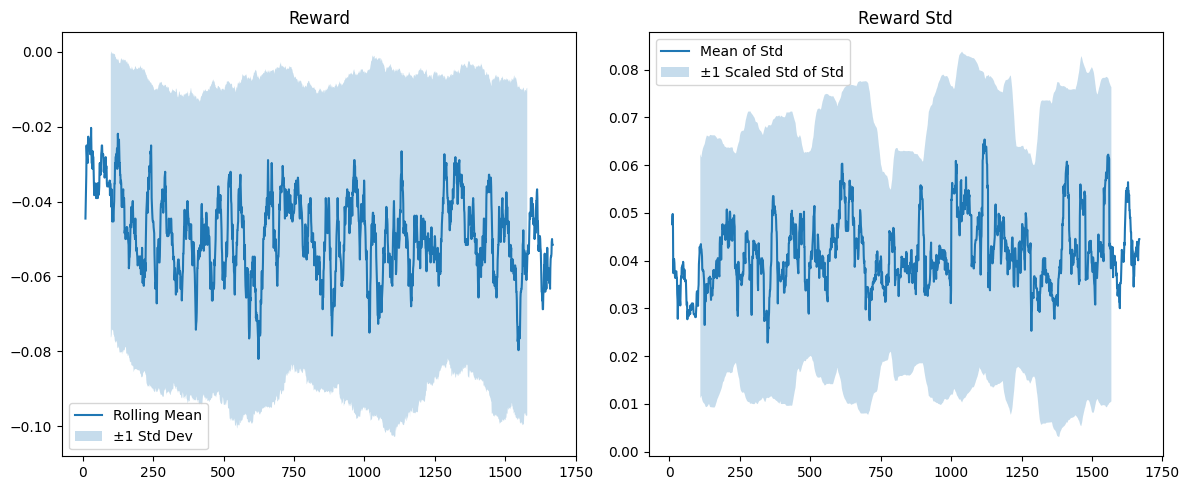

In [27]:
steps = df["step"]
col = df["Reward"]

plt.figure(figsize=(12, 5))

beta = 1
window_size = 20
slow_window = 10 * window_size

plt.subplot(1, 2, 1)
mean = col.rolling(window=window_size, center=True).mean()
std = col.rolling(window=slow_window, center=True).std()
std_mean = col.rolling(window=slow_window, center=True).mean()

plt.plot(steps, mean, label="Rolling Mean")
plt.fill_between(steps, std_mean - beta * std, std_mean + beta * std, alpha=0.25, label=f"±{beta} Std Dev")
plt.title("Reward")
plt.legend()

plt.subplot(1, 2, 2)
window_size = 20
# std_mean = col.rolling(window=window_size, center=True).std()
# std_std_mean = std_mean.rolling(window=10 * window_size, center=True).mean()
# std_std = std_mean.rolling(window=10 * window_size, center=True).std()
std_fast = col.rolling(window=window_size, center=True).std()
std_std_mean = std_fast.rolling(window=slow_window, center=True).mean()
std_std = std_fast.rolling(window=slow_window, center=True).std()
raw_std_std = std_std * np.sqrt(window_size)
lower_bound = np.maximum(0, std_std_mean - beta * raw_std_std)
upper_bound = std_std_mean + beta * raw_std_std

plt.plot(steps, std_fast, label="Mean of Std")
plt.fill_between(steps, lower_bound, upper_bound, alpha=0.25, label=f"±{beta} Scaled Std of Std")
plt.title("Reward Std")
plt.legend()

plt.tight_layout()
plt.show()

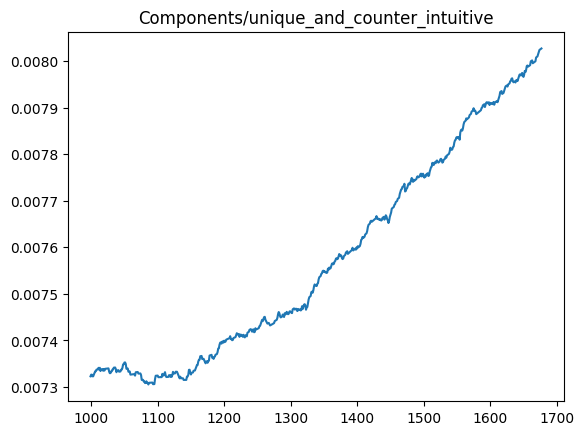

In [16]:
plot_rolling(df["Components/unique_and_counter_intuitive"], 1000)

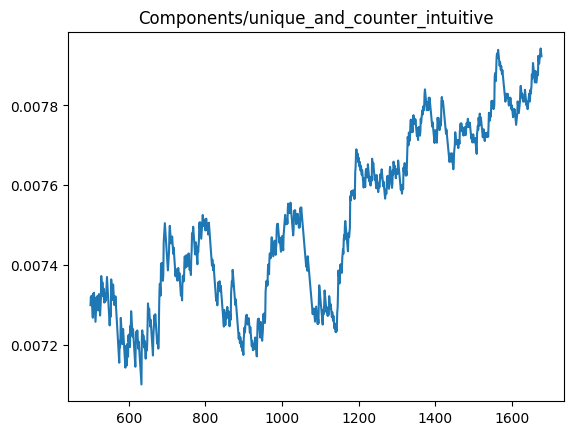

In [23]:
plot_ema(df["Components/unique_and_counter_intuitive"], start=500)

In [239]:
df.columns

Index(['Components/legal_rate', 'step', 'Components/uniqueness_rate',
       'Components/counter_intuitive_rate',
       'Components/counter_intuitive_rate_given_unique',
       'Components/unique_and_counter_intuitive', 'Components/entropy',
       'Components/piece_counts', 'Components/dist_inter_fen',
       'Components/dist_intra_fen', 'Components/dist_inter_pv',
       'Components/dist_intra_pv', 'Components/intra_dist',
       'Components/inter_dist', 'Components/all_dist',
       'Components/pass_diversity_filtering', 'Components/move_match_rate',
       'Components/cp_loss', 'Reward', 'Loss/Total Loss', 'Loss/RL Grad Norm',
       'Loss/KL divergence', 'Loss/Clips', 'Loss/learning_rate'],
      dtype='object')

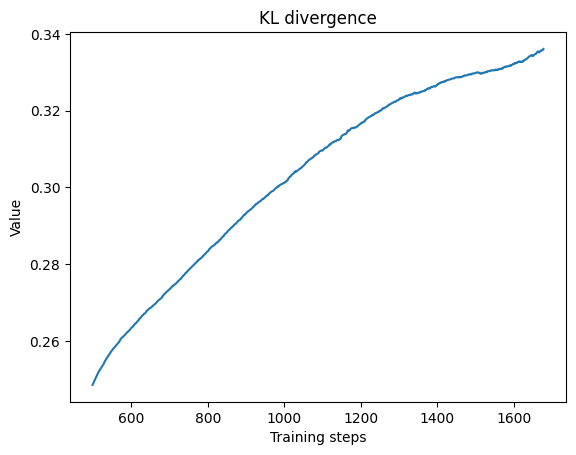

In [24]:
plot_rolling(df["Loss/KL divergence"], window=500)
plt.title("KL divergence")
plt.xlabel("Training steps")
# plt.ylabel("Percentage of positions")
plt.ylabel("Value")
# plt.savefig("./slides/figures/kl_divergence.pdf")
plt.show()

C:\Users\aatus\AppData\Local\Temp\ipykernel_10264\2817206399.py:9: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


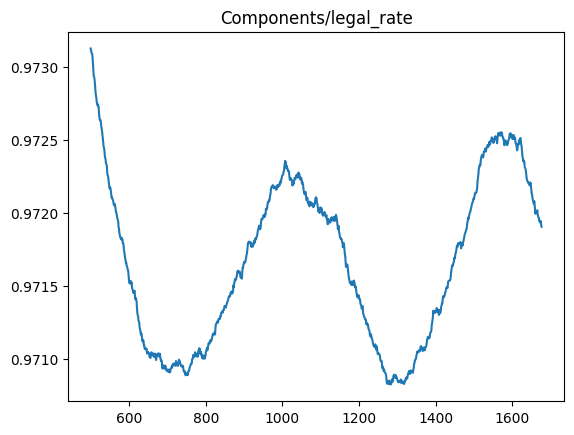

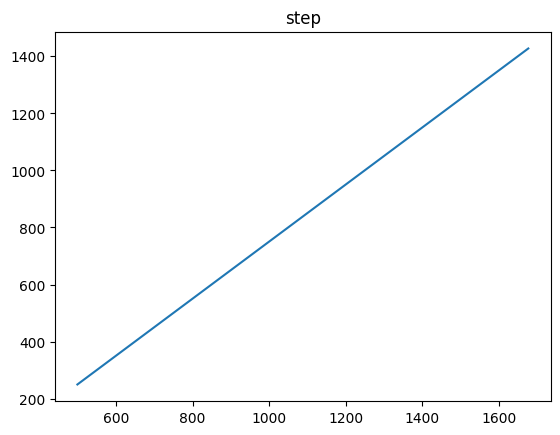

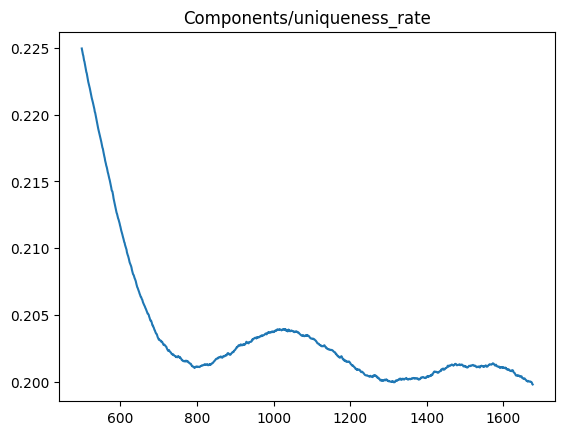

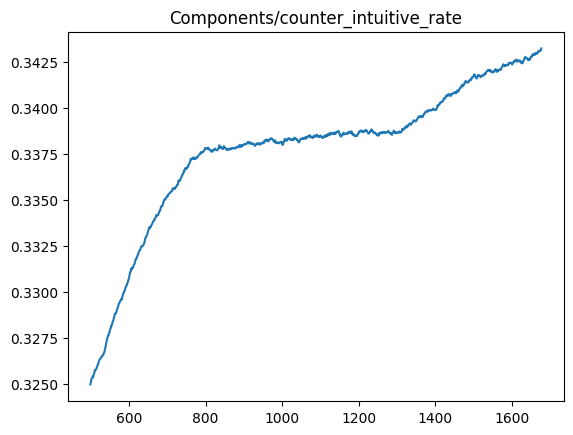

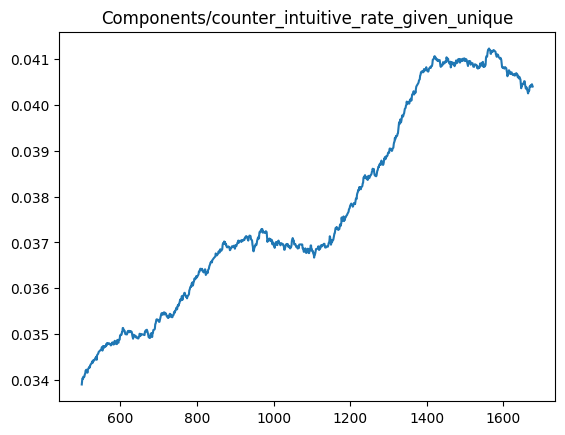

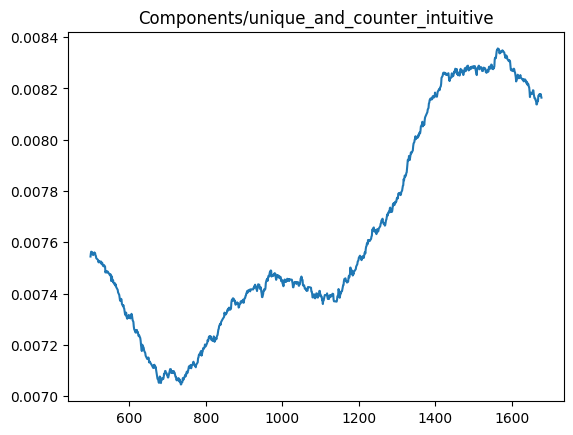

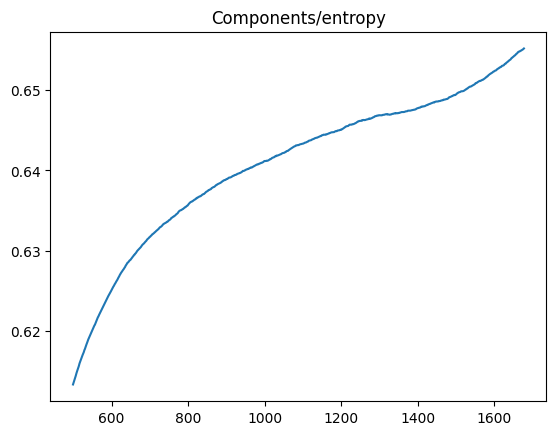

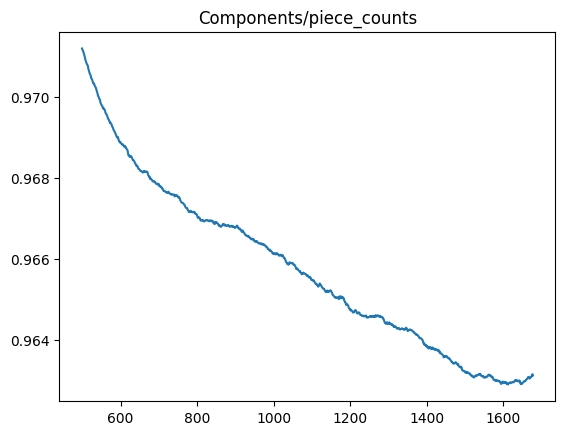

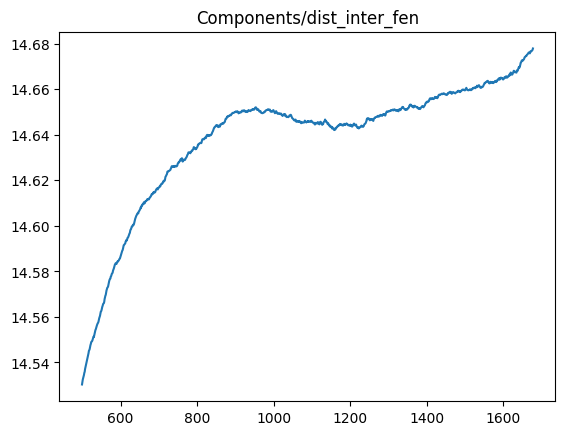

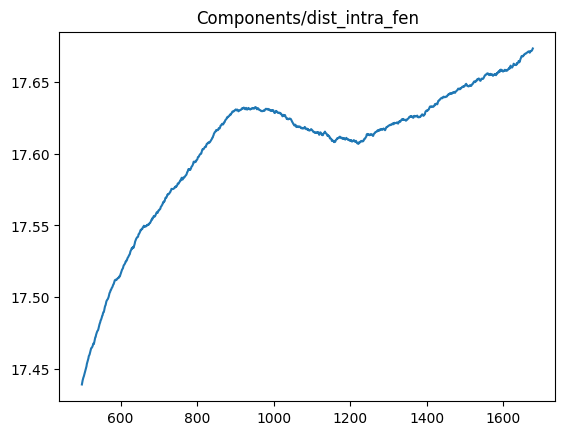

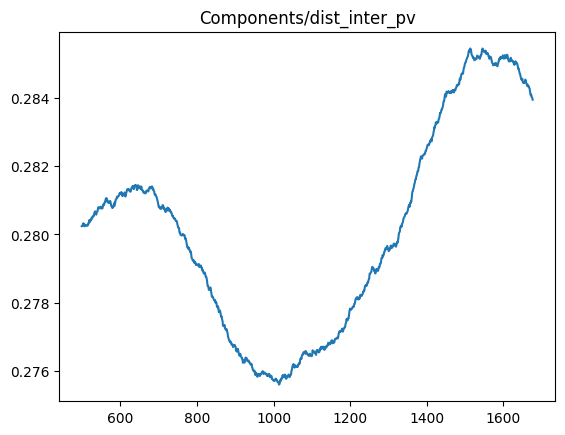

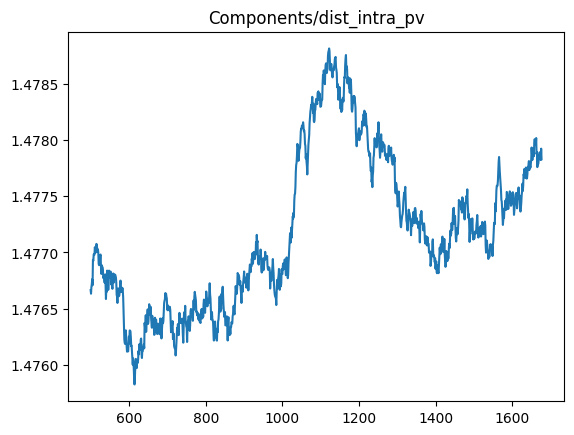

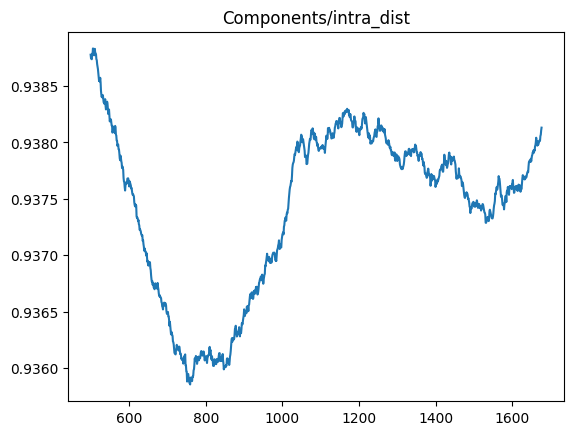

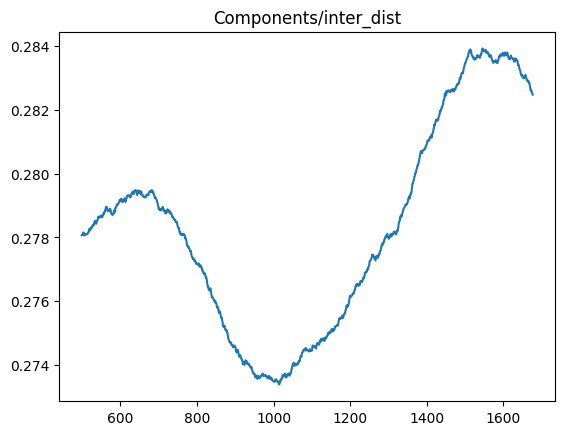

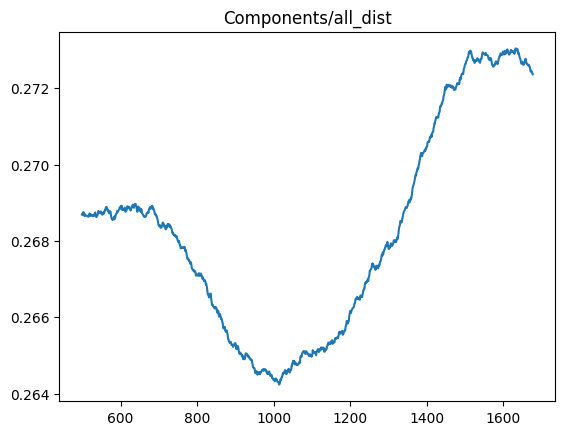

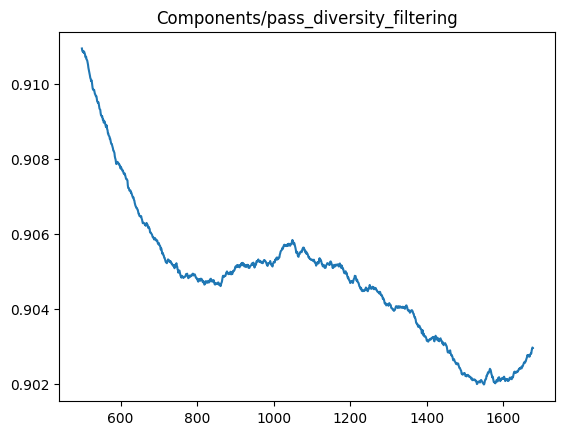

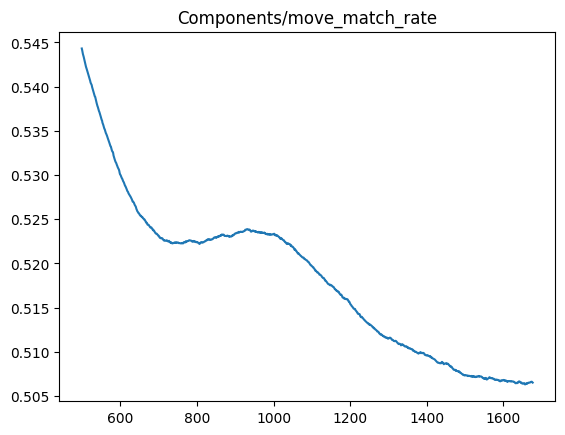

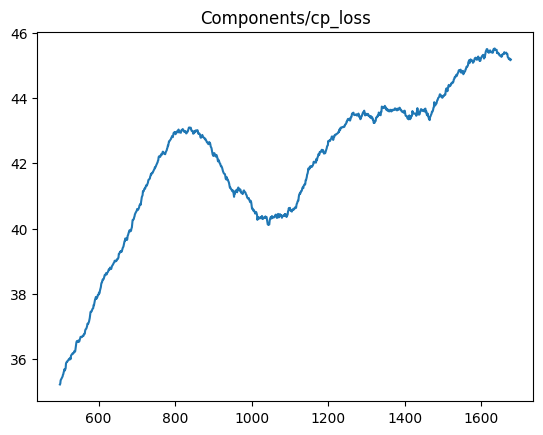

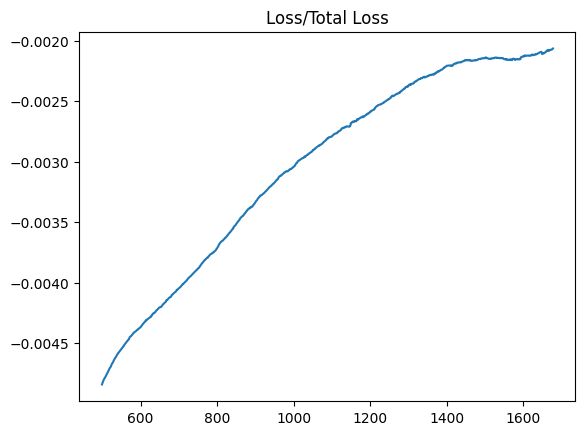

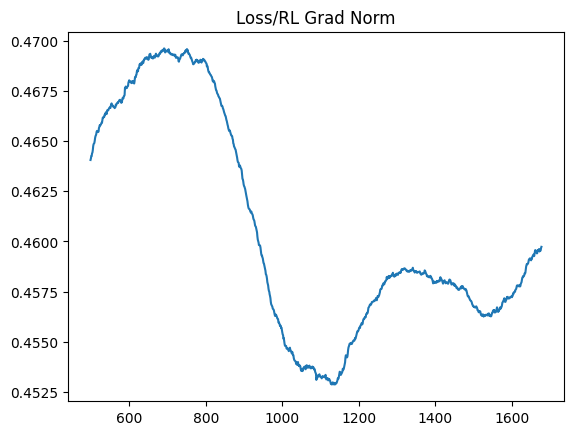

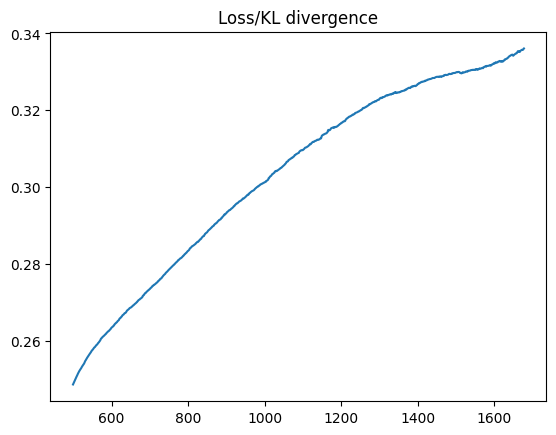

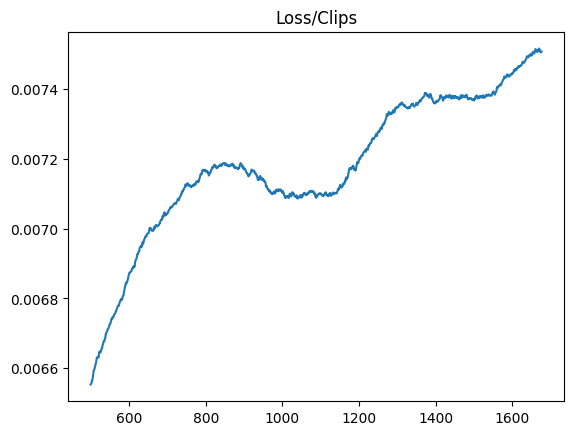

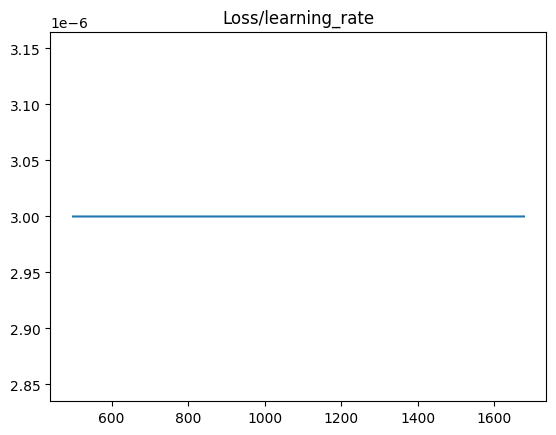

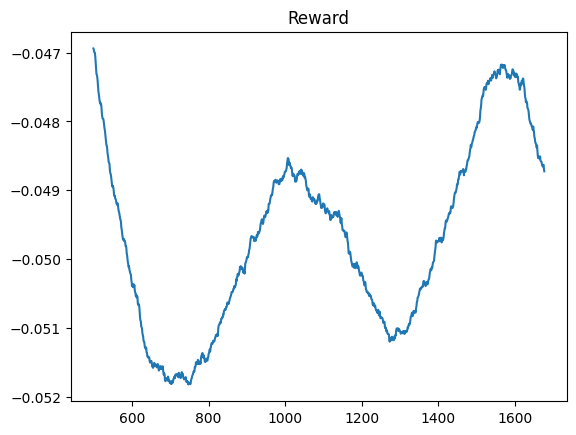

In [25]:
plot_all(df, window=500, type="rolling")